# Airline Tweet Sentiment Analysis
### End-to-End Data Science Project

**Dataset:** US Airline Twitter Sentiment (14,640 tweets · 6 airlines · February 2015)  
**Goal:** Analyze customer sentiment on Twitter and build a sentiment prediction model.

---
##  Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Load & Explore Data](#2-load--explore-data)
3. [Data Cleaning & Preprocessing](#3-data-cleaning--preprocessing)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
5. [Word Cloud Analysis](#5-word-cloud-analysis)
6. [Time Series Analysis](#6-time-series-analysis)
7. [Machine Learning Model](#7-machine-learning-model)
8. [Model Evaluation](#8-model-evaluation)
9. [Predict New Tweets](#9-predict-new-tweets)
10. [Conclusions](#10-conclusions)


## 1. Setup & Imports

In [1]:
# Install required libraries (run once)

!pip install pandas plotly wordcloud matplotlib scikit-learn seaborn -q

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP & ML
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from collections import Counter

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(" All libraries imported successfully!")
print(f"   Pandas    : {pd.__version__}")
print(f"   Numpy     : {np.__version__}")
print(f"   Sklearn   : {__import__('sklearn').__version__}")

 All libraries imported successfully!
   Pandas    : 2.3.3
   Numpy     : 2.2.6
   Sklearn   : 1.7.2


## 2. Load & Explore Data

In [3]:
# Load dataset
df = pd.read_csv('data/tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [6]:
df.shape

(14640, 15)

In [7]:
df.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [8]:
df.tail()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)
14639,569587140490866689,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2015-02-22 11:58:51 -0800,"dallas, TX",NaN


In [9]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [10]:
# Basic statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tweet_id,14640.0,NaN,NaN,NaN,569218351767499200.0,779111158481835.875,567588278875213824.0,568559178101439488.0,569477857923110912.0,569890473289000960.0,570310600460525568.0
airline_sentiment,14640,3,negative,9178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline_sentiment_confidence,14640.0,NaN,NaN,NaN,0.900169,0.16283,0.335,0.6923,1.0,1.0,1.0
negativereason,9178,10,Customer Service Issue,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
negativereason_confidence,10522.0,NaN,NaN,NaN,0.638298,0.33044,0.0,0.3606,0.6706,1.0,1.0
airline,14640,6,United,3822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline_sentiment_gold,40,3,negative,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,14640,7701,JetBlueNews,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
negativereason_gold,32,13,Customer Service Issue,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retweet_count,14640.0,NaN,NaN,NaN,0.08265,0.745778,0.0,0.0,0.0,0.0,44.0


In [11]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
negativereason_gold,14608,99.78
airline_sentiment_gold,14600,99.73
tweet_coord,13621,93.04
negativereason,5462,37.31
user_timezone,4820,32.92
tweet_location,4733,32.33
negativereason_confidence,4118,28.13


In [12]:
# Unique values in key columns
print("Airlines:", df['airline'].unique().tolist())
print("Sentiments:", df['airline_sentiment'].unique().tolist())
print("Negative Reasons:", df['negativereason'].nunique(), "unique reasons")
print("\nSentiment Counts:")
print(df['airline_sentiment'].value_counts())

Airlines: ['Virgin America', 'United', 'Southwest', 'Delta', 'US Airways', 'American']
Sentiments: ['neutral', 'positive', 'negative']
Negative Reasons: 10 unique reasons

Sentiment Counts:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


## 3. Data Cleaning & Preprocessing

In [13]:
def clean_text(text):
    """Clean tweet text for NLP processing."""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # keep hashtag words
    text = re.sub(r'[^a-z\s]', '', text)              # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()          # normalize whitespace
    return text



In [14]:
# Apply cleaning
df['text_clean'] = df['text'].apply(clean_text)

In [15]:
# Parse datetime
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True, errors='coerce')
df['date']    = df['tweet_created'].dt.date
df['hour']    = df['tweet_created'].dt.hour
df['weekday'] = df['tweet_created'].dt.day_name()
df['month']   = df['tweet_created'].dt.to_period('M').astype(str)

In [16]:
# Tweet length features
df['tweet_length']    = df['text'].str.len()
df['word_count']      = df['text_clean'].str.split().str.len()
df['has_exclamation'] = df['text'].str.contains('!').astype(int)
df['has_question']    = df['text'].str.contains('\?').astype(int)

print(f"   Sample cleaned tweet:")
print(f"   Before: {df['text'].iloc[1]}")
print(f"   After : {df['text_clean'].iloc[1]}")

   Sample cleaned tweet:
   Before: @VirginAmerica plus you've added commercials to the experience... tacky.
   After : plus youve added commercials to the experience tacky


In [17]:
# Encode sentiment as numbers for correlation analysis
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['sentiment_num'] = df['airline_sentiment'].map(sentiment_map)

df[['tweet_length', 'word_count', 'retweet_count',
    'has_exclamation', 'has_question', 'sentiment_num']].describe().round(2)

,tweet_length,word_count,retweet_count,has_exclamation,has_question,sentiment_num
count,14640.00,14640.00,14640.00,14640.00,14640.00,14640.00
mean,103.82,15.93,0.08,0.22,0.25,0.53
std,36.28,6.78,0.75,0.41,0.43,0.76
min,12.00,1.00,0.00,0.00,0.00,0.00
25%,77.00,11.00,0.00,0.00,0.00,0.00
50%,114.00,17.00,0.00,0.00,0.00,0.00
75%,136.00,21.00,0.00,0.00,1.00,1.00
max,186.00,31.00,44.00,1.00,1.00,2.00


## 4. Exploratory Data Analysis

TypeError: Figure.savefig() missing 1 required positional argument: 'fname'

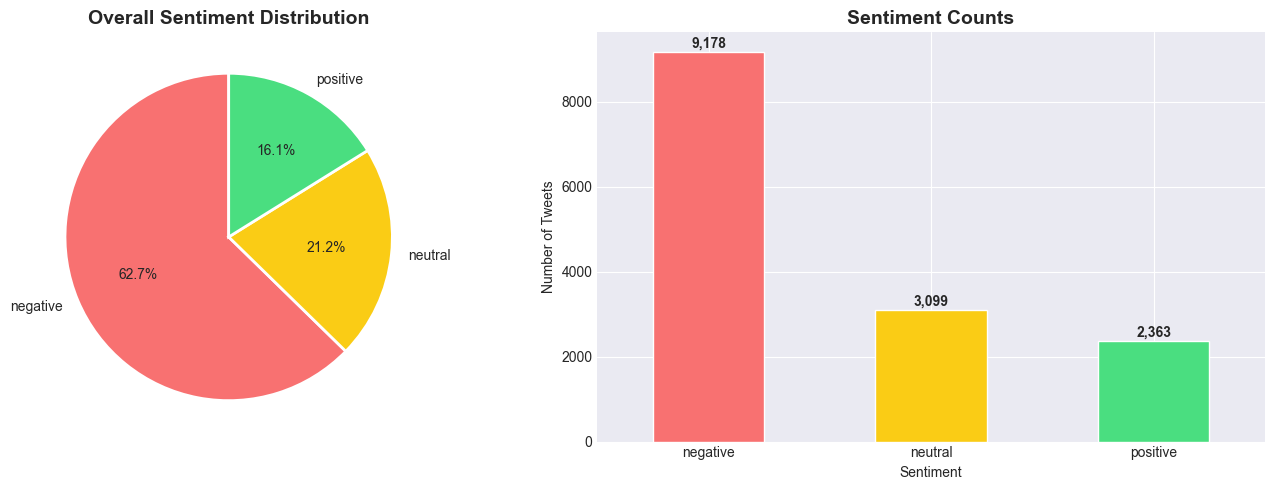

In [18]:
# Sentiment Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
sentiment_counts = df['airline_sentiment'].value_counts()
colors = ['#f87171', '#facc15', '#4ade80']
axes[0].pie(sentiment_counts, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')

# Bar chart
sentiment_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Sentiment Counts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Tweets')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(dpi=150, bbox_inches='tight')
plt.show()
print(sentiment_counts)

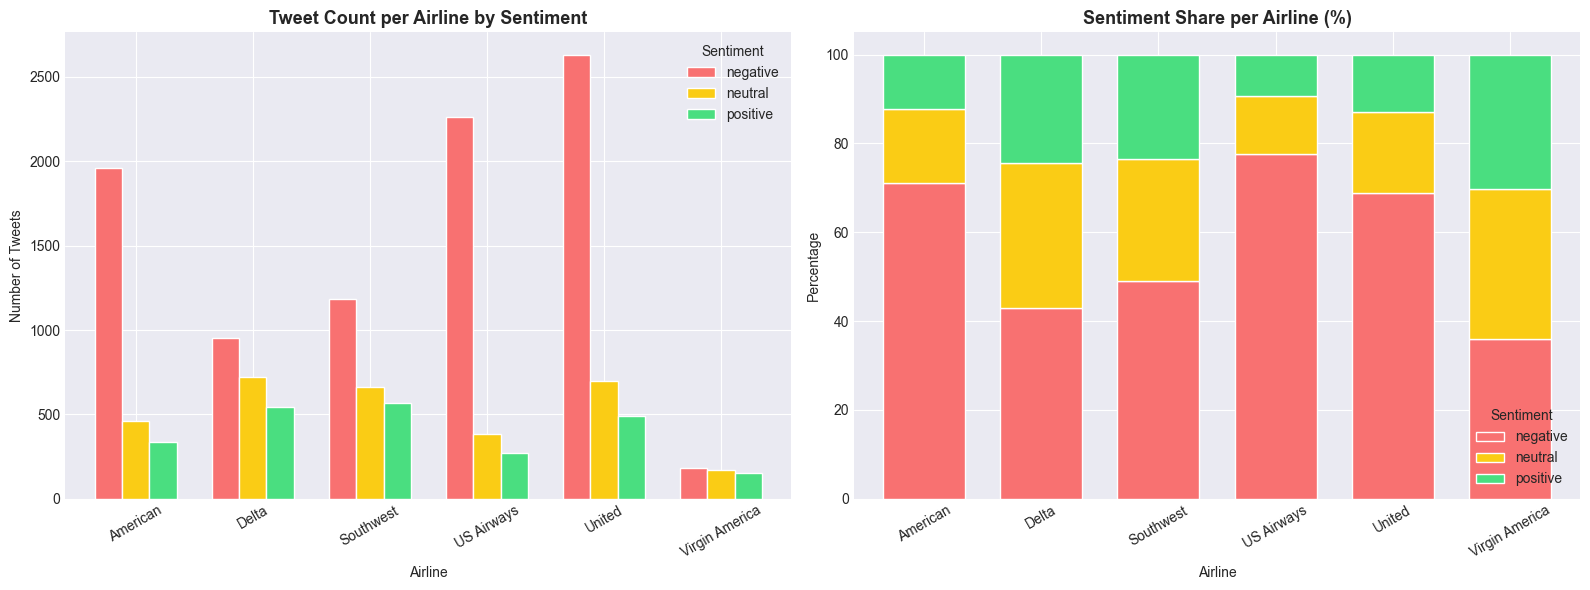

In [19]:
# Sentiment per Airline
import os
os.makedirs('plots', exist_ok=True)

airline_sentiment = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
airline_sentiment_pct = airline_sentiment.div(airline_sentiment.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
airline_sentiment.plot(kind='bar', ax=axes[0],
                       color=['#f87171', '#facc15', '#4ade80'],
                       edgecolor='white', width=0.7)
axes[0].set_title('Tweet Count per Airline by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Airline')
axes[0].set_ylabel('Number of Tweets')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Sentiment')

# Percentage stacked
airline_sentiment_pct.plot(kind='bar', stacked=True, ax=axes[1],
                            color=['#f87171', '#facc15', '#4ade80'],
                            edgecolor='white', width=0.7)
axes[1].set_title('Sentiment Share per Airline (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Airline')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Sentiment', loc='lower right')

plt.tight_layout()
plt.savefig('plots/02_airline_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

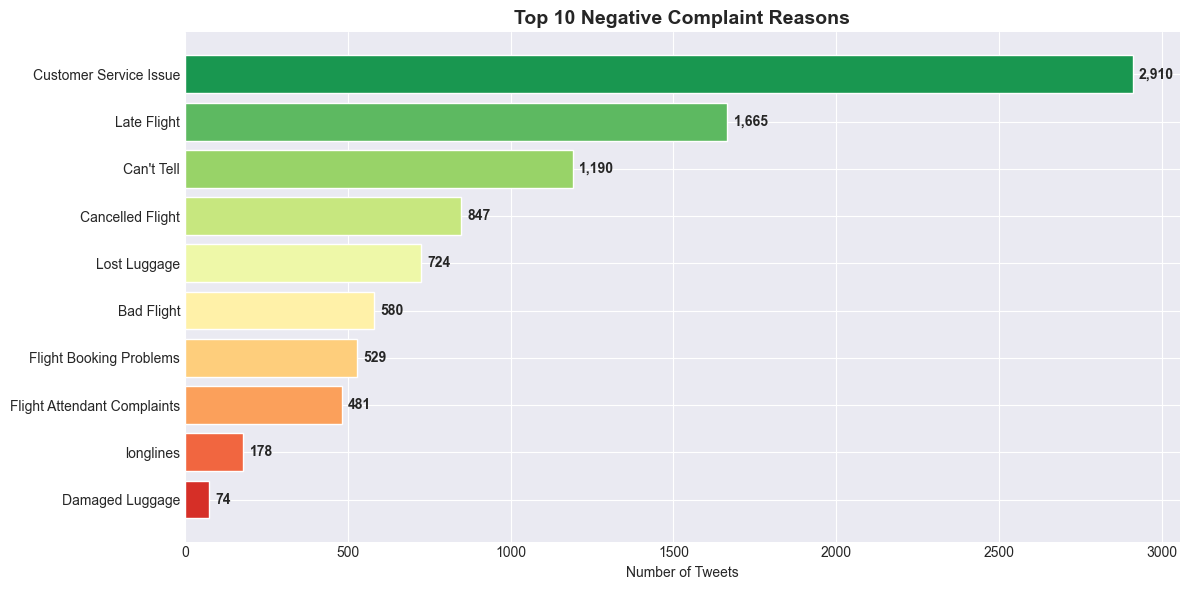

In [20]:
# Negative Reasons
neg_reasons = (df[df['airline_sentiment'] == 'negative']['negativereason']
               .value_counts().dropna().head(10))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(neg_reasons.index, neg_reasons.values,
               color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(neg_reasons))),
               edgecolor='white')
ax.set_title('Top 10 Negative Complaint Reasons', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Tweets')
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_negative_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

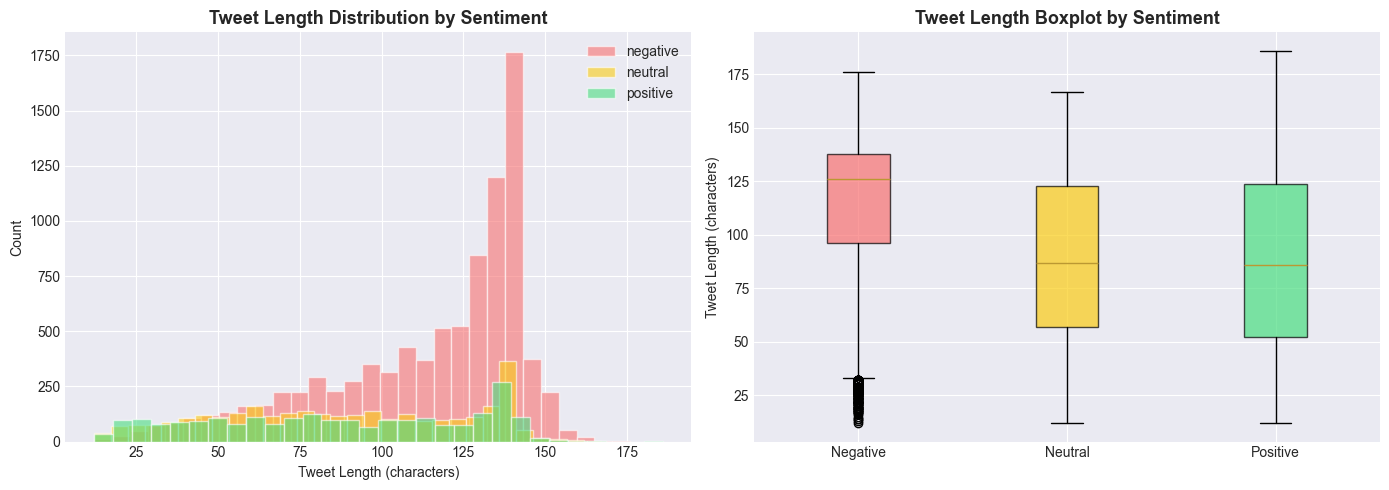

Average tweet length by sentiment:
airline_sentiment
negative    113.9
neutral      87.4
positive     86.1
Name: tweet_length, dtype: float64


In [21]:
# Tweet Length Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_colors = {'negative': '#f87171', 'neutral': '#facc15', 'positive': '#4ade80'}

for sentiment, color in sentiment_colors.items():
    subset = df[df['airline_sentiment'] == sentiment]['tweet_length']
    axes[0].hist(subset, bins=30, alpha=0.6, label=sentiment, color=color, edgecolor='white')

axes[0].set_title('Tweet Length Distribution by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tweet Length (characters)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
data_by_sentiment = [df[df['airline_sentiment'] == s]['tweet_length'].values
                     for s in ['negative', 'neutral', 'positive']]
bp = axes[1].boxplot(data_by_sentiment, labels=['Negative', 'Neutral', 'Positive'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['#f87171', '#facc15', '#4ade80']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Tweet Length Boxplot by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tweet Length (characters)')

plt.tight_layout()
plt.savefig('plots/04_tweet_length.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average tweet length by sentiment:")
print(df.groupby('airline_sentiment')['tweet_length'].mean().round(1))

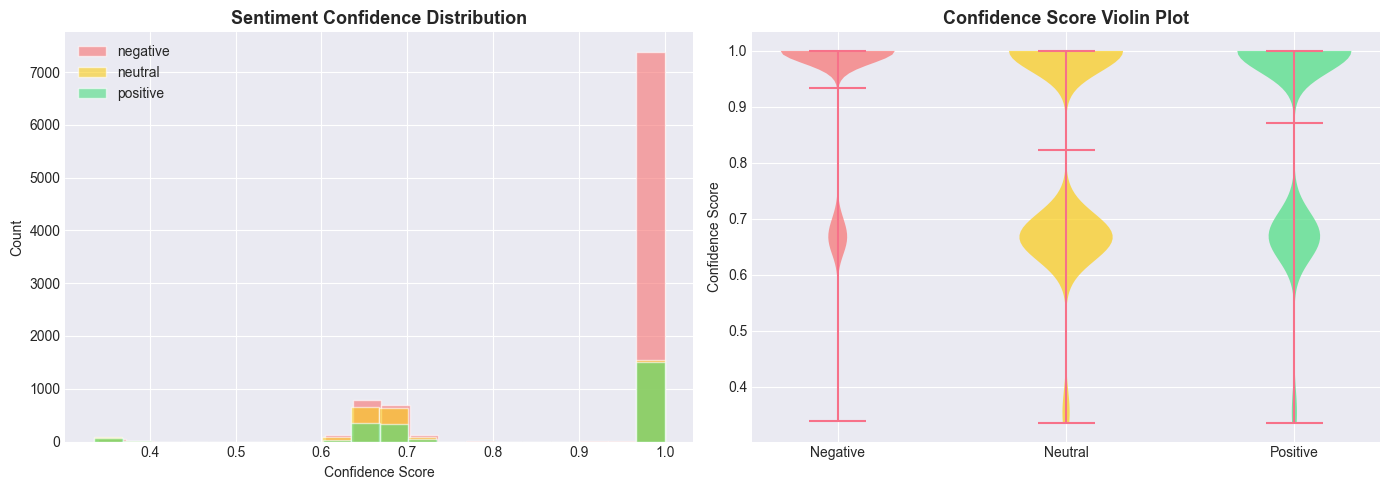

In [22]:
# Confidence Score Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sentiment, color in sentiment_colors.items():
    subset = df[df['airline_sentiment'] == sentiment]['airline_sentiment_confidence']
    axes[0].hist(subset, bins=20, alpha=0.6, label=sentiment, color=color, edgecolor='white')

axes[0].set_title('Sentiment Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Violin plot
df_conf = df[['airline_sentiment', 'airline_sentiment_confidence']].dropna()
parts = axes[1].violinplot(
    [df_conf[df_conf['airline_sentiment'] == s]['airline_sentiment_confidence'].values
     for s in ['negative', 'neutral', 'positive']],
    positions=[1, 2, 3], showmeans=True)
for pc, color in zip(parts['bodies'], ['#f87171', '#facc15', '#4ade80']):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[1].set_title('Confidence Score Violin Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Confidence Score')

plt.tight_layout()
plt.savefig('plots/05_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

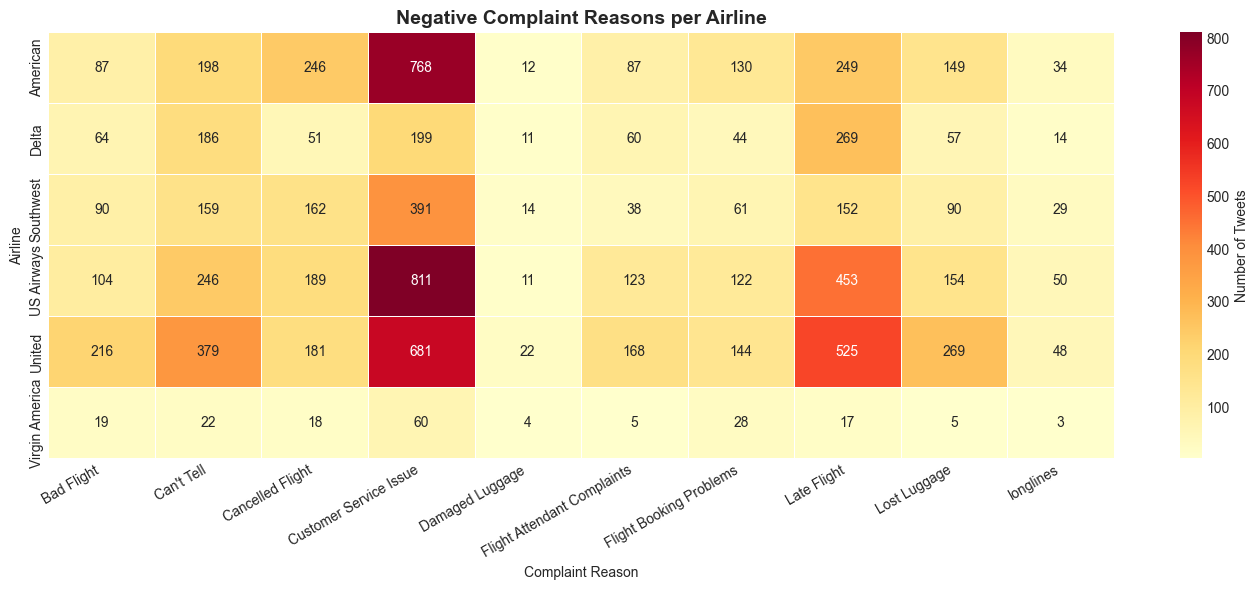

In [23]:
# Negative Reason per Airline Heatmap
neg_df = df[df['airline_sentiment'] == 'negative']
heatmap_data = neg_df.groupby(['airline', 'negativereason']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Number of Tweets'})
plt.title('Negative Complaint Reasons per Airline', fontsize=14, fontweight='bold')
plt.xlabel('Complaint Reason')
plt.ylabel('Airline')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plots/06_heatmap_complaints.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Word Cloud Analysis

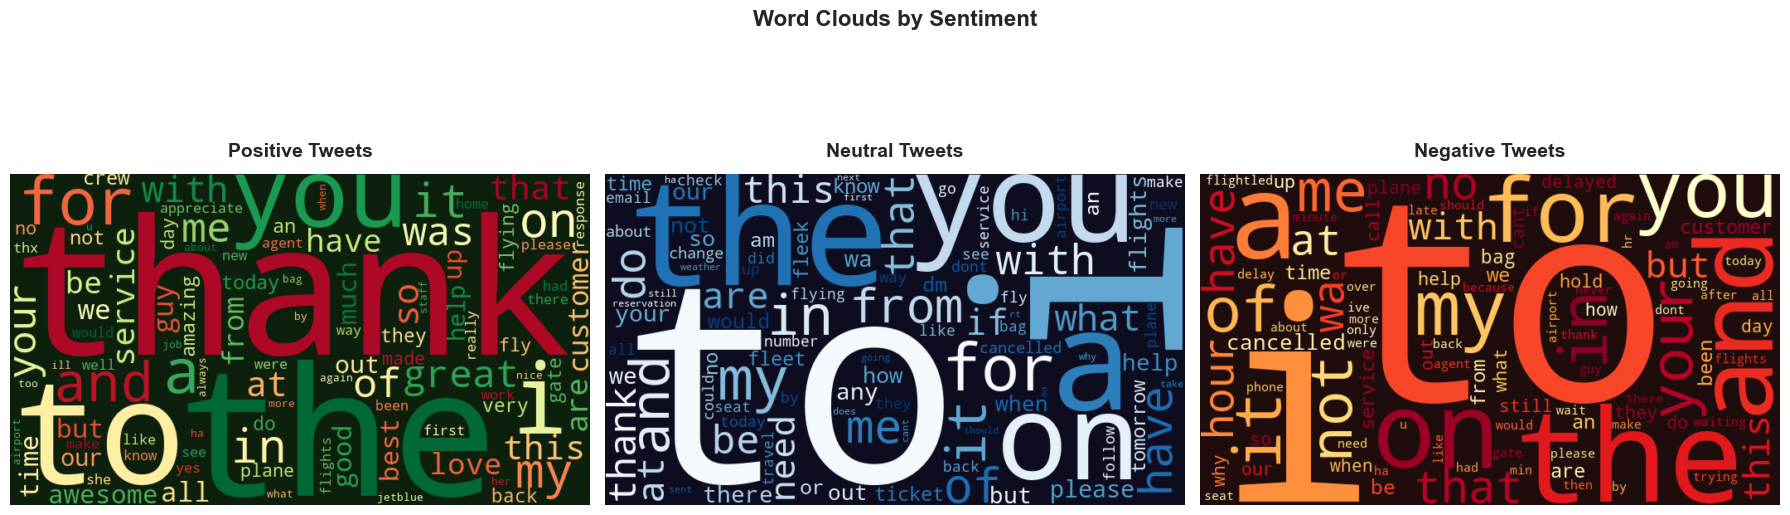

In [24]:
# Word Clouds for each Sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

configs = [
    ('positive', 'RdYlGn',   '#0d1f0d'),
    ('neutral',  'Blues',    '#0d0d1f'),
    ('negative', 'YlOrRd',   '#1f0d0d'),
]

for ax, (sentiment, cmap, bg) in zip(axes, configs):
    corpus = ' '.join(df[df['airline_sentiment'] == sentiment]['text_clean'].dropna())
    wc = WordCloud(
        width=700, height=400,
        background_color=bg,
        colormap=cmap,
        max_words=100,
        collocations=False,
        stopwords={'flight', 'airline', 'im', 'get', 'just', 'now',
                   'us', 'amp', 'will', 'one', 'can', 'got'},
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment.capitalize()} Tweets', fontsize=14,
                 fontweight='bold', pad=12)

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/07_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

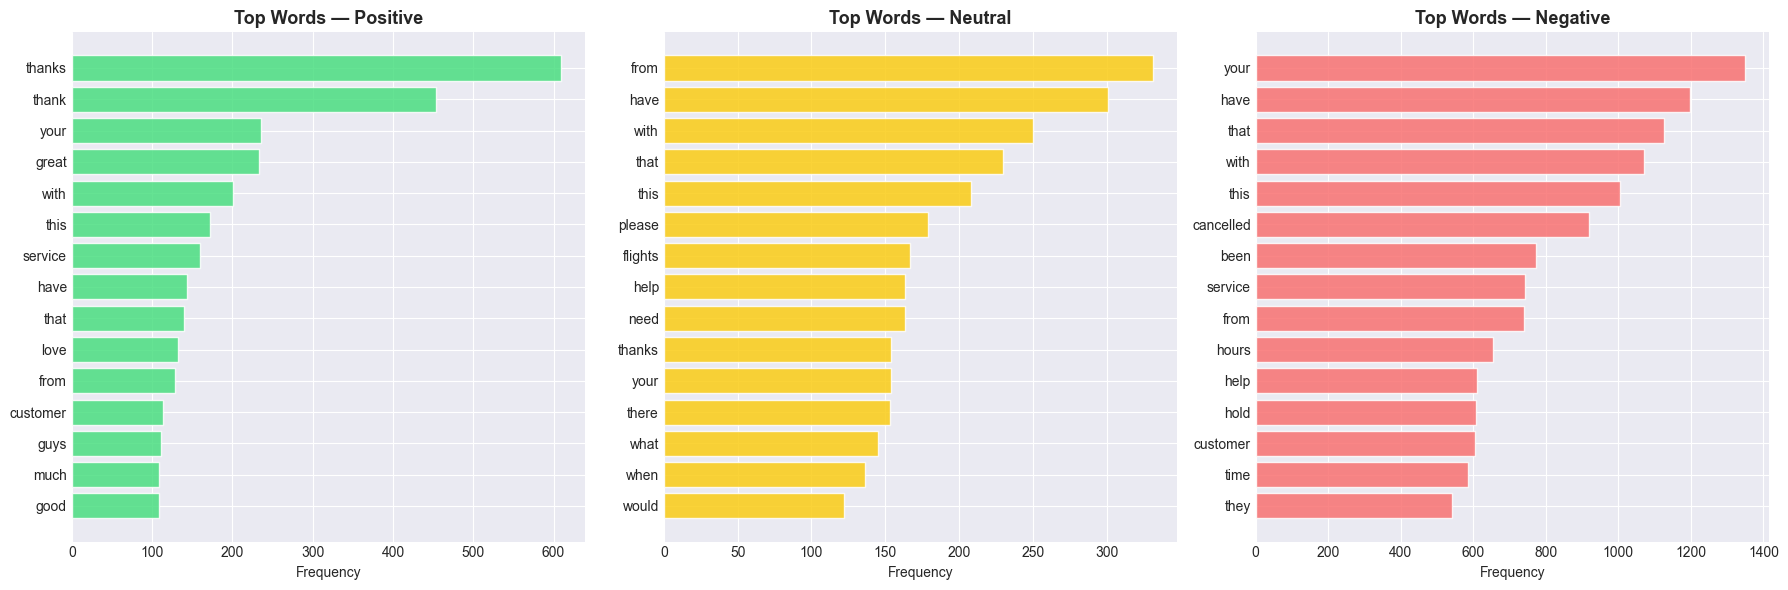

In [25]:
# Top Words per Sentiment (Bar)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
stopwords_custom = {'flight', 'airline', 'im', 'get', 'just', 'now',
                    'us', 'amp', 'will', 'one', 'can', 'got', 'us'}

colors_list = ['#4ade80', '#facc15', '#f87171']
sentiments   = ['positive', 'neutral', 'negative']

for ax, sentiment, color in zip(axes, sentiments, colors_list):
    corpus = ' '.join(df[df['airline_sentiment'] == sentiment]['text_clean'].dropna())
    words  = [w for w in corpus.split() if w not in stopwords_custom and len(w) > 3]
    top_words = pd.Series(Counter(words).most_common(15)).apply(pd.Series)
    top_words.columns = ['word', 'count']
    top_words = top_words.sort_values('count')

    ax.barh(top_words['word'], top_words['count'], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Top Words — {sentiment.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('plots/08_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Time Series Analysis

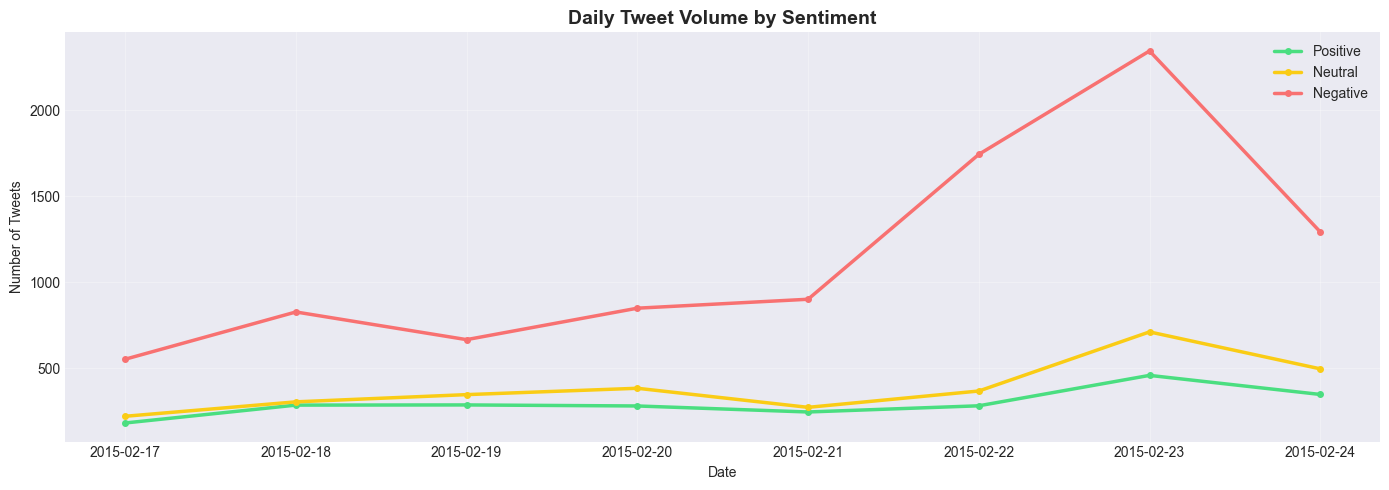

In [26]:
# Daily Tweet Volume
df['date'] = pd.to_datetime(df['date'])
daily = df.groupby(['date', 'airline_sentiment']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
for sentiment, color in [('positive','#4ade80'),('neutral','#facc15'),('negative','#f87171')]:
    if sentiment in daily.columns:
        ax.plot(daily.index, daily[sentiment], label=sentiment.capitalize(),
                color=color, linewidth=2.5, marker='o', markersize=4)

ax.set_title('Daily Tweet Volume by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Tweets')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/09_daily_volume.png', dpi=150, bbox_inches='tight')
plt.show()

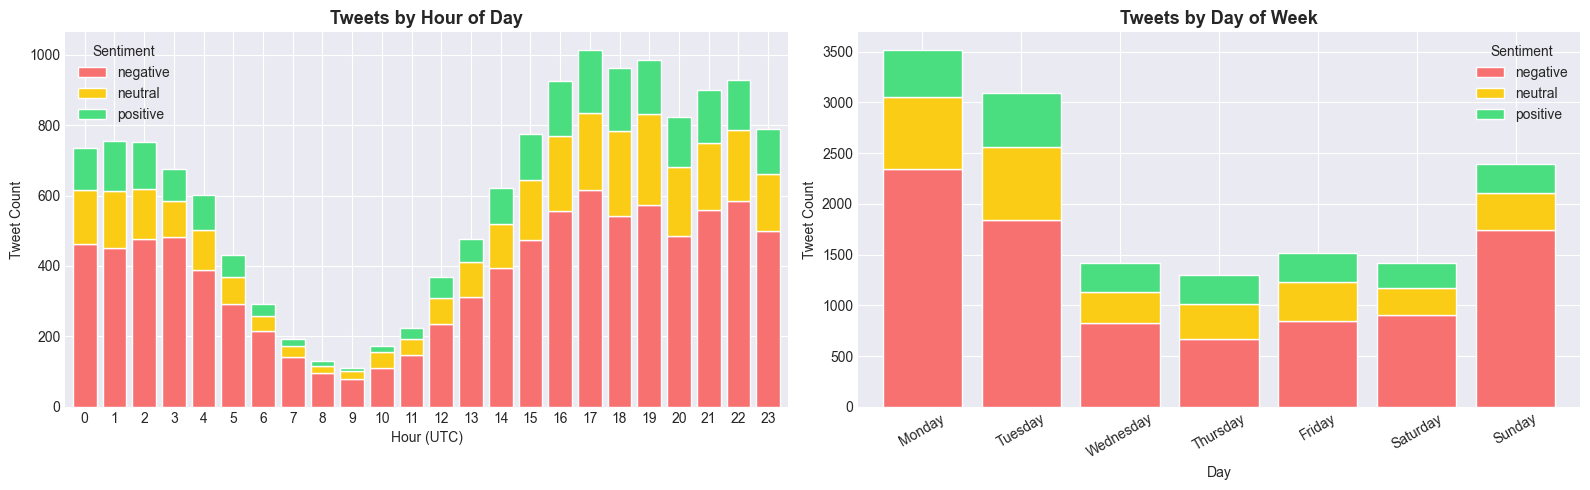

In [27]:
# Hourly & Weekday Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly
hourly = df.groupby(['hour', 'airline_sentiment']).size().unstack(fill_value=0)
hourly.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#f87171', '#facc15', '#4ade80'], edgecolor='white', width=0.8)
axes[0].set_title('Tweets by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Tweet Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

# Weekday
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday = df.groupby(['weekday', 'airline_sentiment']).size().unstack(fill_value=0)
weekday = weekday.reindex([w for w in weekday_order if w in weekday.index])
weekday.plot(kind='bar', stacked=True, ax=axes[1],
             color=['#f87171', '#facc15', '#4ade80'], edgecolor='white', width=0.8)
axes[1].set_title('Tweets by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Tweet Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('plots/10_hourly_weekday.png', dpi=150, bbox_inches='tight')
plt.show()

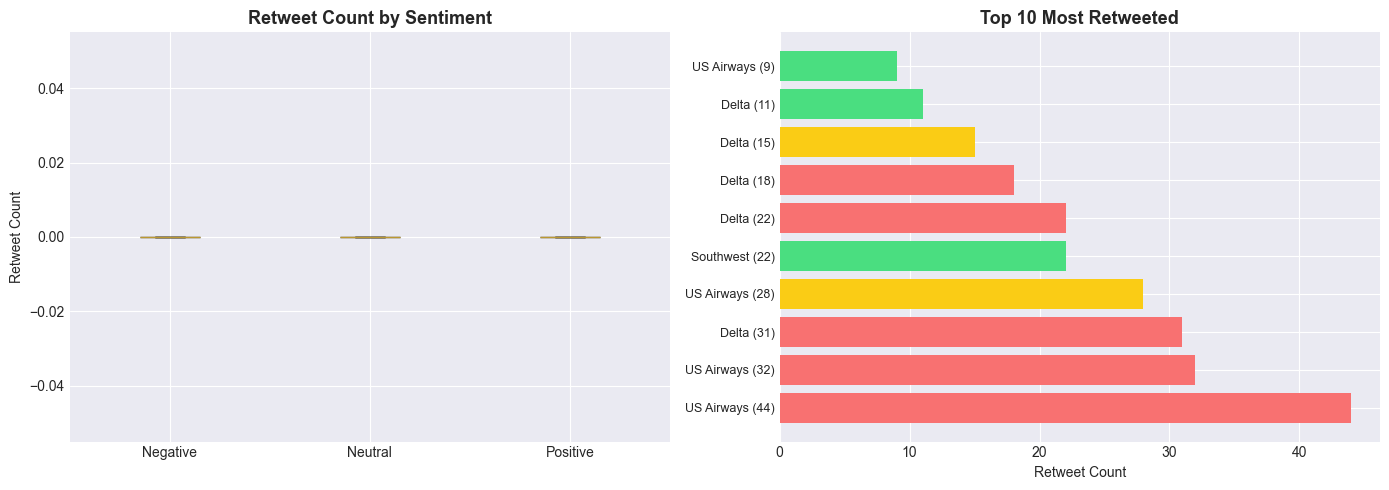

In [28]:
# Retweet Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retweet count by sentiment
rt_data = [df[df['airline_sentiment'] == s]['retweet_count'].values
           for s in ['negative', 'neutral', 'positive']]
bp = axes[0].boxplot(rt_data, labels=['Negative', 'Neutral', 'Positive'],
                     patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['#f87171', '#facc15', '#4ade80']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Retweet Count by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Retweet Count')

# Top retweeted tweets
top_rt = df.nlargest(10, 'retweet_count')[['airline', 'airline_sentiment', 'retweet_count', 'text']]
axes[1].barh(range(len(top_rt)), top_rt['retweet_count'],
             color=[sentiment_colors[s] for s in top_rt['airline_sentiment']])
axes[1].set_yticks(range(len(top_rt)))
axes[1].set_yticklabels([f"{r['airline']} ({r['retweet_count']})" 
                          for _, r in top_rt.iterrows()], fontsize=9)
axes[1].set_title('Top 10 Most Retweeted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Retweet Count')

plt.tight_layout()
plt.savefig('plots/11_retweets.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Machine Learning Model

In [29]:
# Prepare Data
sample = df[['text_clean', 'airline_sentiment']].dropna()
X = sample['text_clean']
y = sample['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training samples : 11,712
Testing samples  : 2,928

Class distribution in training set:
airline_sentiment
negative    7343
neutral     2479
positive    1890
Name: count, dtype: int64


In [30]:
# Build 3 Models & Compare
models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')),
        ('clf',   MultinomialNB(alpha=0.5))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')),
        ('clf',   LogisticRegression(max_iter=1000, random_state=42, C=1.0))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,1), stop_words='english')),
        ('clf',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    train_acc = pipeline.score(X_train, y_train)
    test_acc  = pipeline.score(X_test,  y_test)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy':  test_acc,
        'CV Mean':        cv_scores.mean(),
        'CV Std':         cv_scores.std(),
    }
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  Train Accuracy : {train_acc:.2%}")
    print(f"  Test Accuracy  : {test_acc:.2%}")
    print(f"  CV (5-fold)    : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")

results_df = pd.DataFrame(results).T
print("\n\n Model Comparison Summary:")
print(results_df.round(4))


  Naive Bayes
  Train Accuracy : 81.65%
  Test Accuracy  : 74.59%
  CV (5-fold)    : 74.48% ± 0.57%

  Logistic Regression
  Train Accuracy : 85.19%
  Test Accuracy  : 76.95%
  CV (5-fold)    : 76.79% ± 0.88%

  Random Forest
  Train Accuracy : 98.97%
  Test Accuracy  : 75.07%
  CV (5-fold)    : 75.30% ± 1.10%


 Model Comparison Summary:
                     Train Accuracy  Test Accuracy  CV Mean  CV Std
Naive Bayes                  0.8165         0.7459   0.7448  0.0057
Logistic Regression          0.8519         0.7695   0.7679  0.0088
Random Forest                0.9897         0.7507   0.7530  0.0110


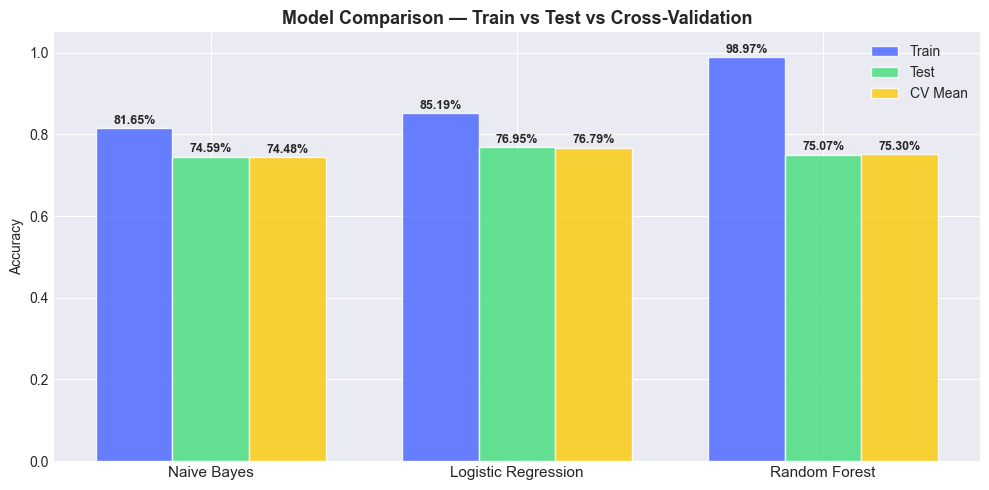

In [31]:
# Model Comparison Chart
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.25
bars1 = ax.bar(x - width, results_df['Train Accuracy'], width, label='Train',
               color='#4f6aff', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x,          results_df['Test Accuracy'],  width, label='Test',
               color='#4ade80', edgecolor='white', alpha=0.85)
bars3 = ax.bar(x + width,  results_df['CV Mean'],        width, label='CV Mean',
               color='#facc15', edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — Train vs Test vs Cross-Validation', fontsize=13, fontweight='bold')
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Evaluation

In [32]:
# Best Model: Logistic Regression
best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test)

print(" Classification Report — Logistic Regression")
print("="*55)
print(classification_report(y_test, y_pred, digits=4))

 Classification Report — Logistic Regression
              precision    recall  f1-score   support

    negative     0.7893    0.9411    0.8586      1835
     neutral     0.6283    0.4226    0.5053       620
    positive     0.8173    0.5581    0.6633       473

    accuracy                         0.7695      2928
   macro avg     0.7450    0.6406    0.6757      2928
weighted avg     0.7597    0.7695    0.7522      2928



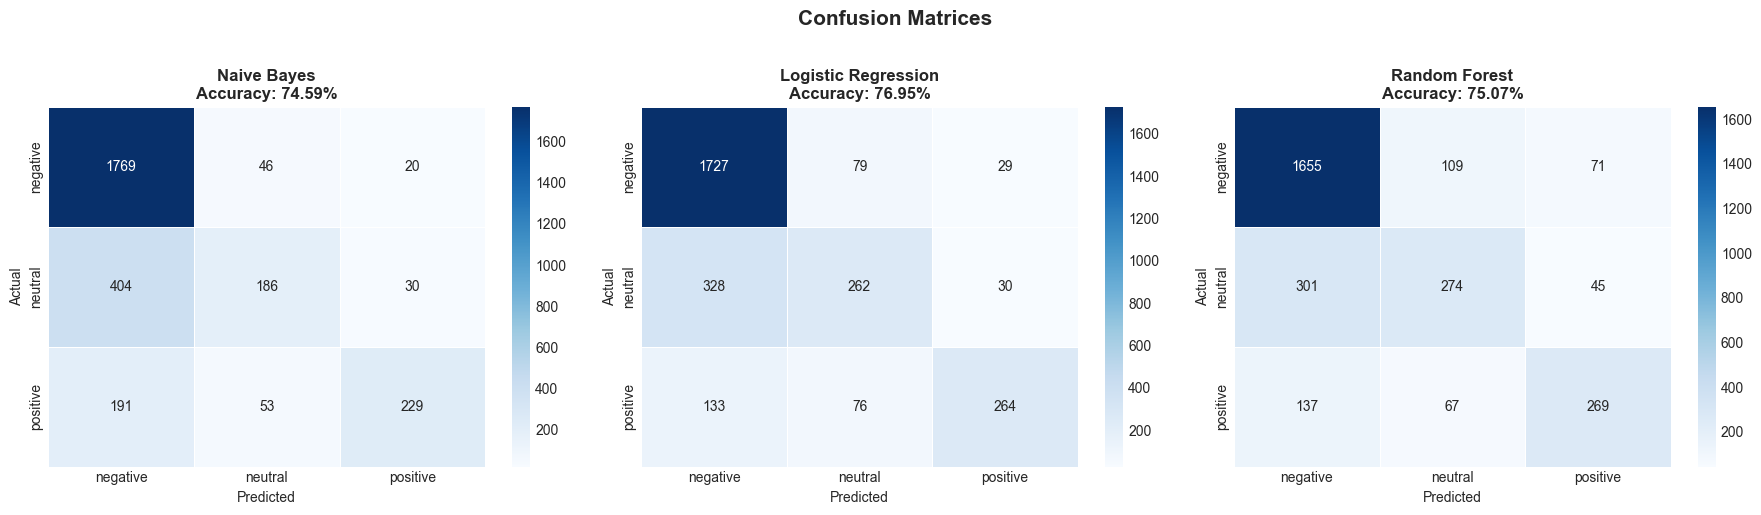

In [33]:
# Confusion Matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['negative', 'neutral', 'positive']

for ax, (name, pipeline) in zip(axes, models.items()):
    y_pred_m = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_m, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5, linecolor='white')
    acc = accuracy_score(y_test, y_pred_m)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/13_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

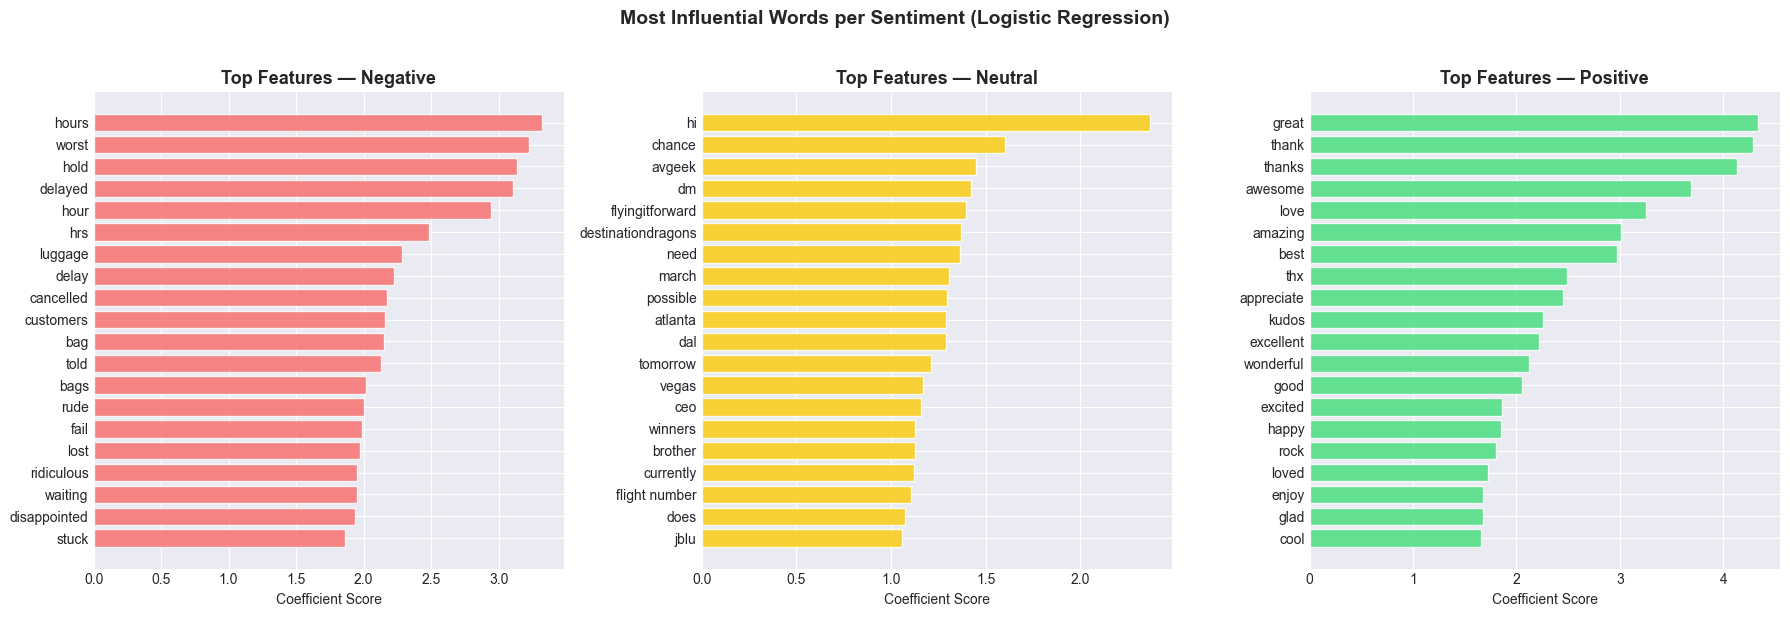

In [34]:
# Feature Importance: Top TF-IDF Words per Class
lr_pipeline = models['Logistic Regression']
vectorizer  = lr_pipeline.named_steps['tfidf']
clf         = lr_pipeline.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (i, sentiment) in zip(axes, enumerate(clf.classes_)):
    top_idx    = clf.coef_[i].argsort()[-20:][::-1]
    top_words  = [feature_names[j] for j in top_idx]
    top_scores = clf.coef_[i][top_idx]

    color = {'negative': '#f87171', 'neutral': '#facc15', 'positive': '#4ade80'}[sentiment]
    ax.barh(top_words[::-1], top_scores[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Top Features — {sentiment.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Coefficient Score')

plt.suptitle('Most Influential Words per Sentiment (Logistic Regression)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Predict New Tweets

In [35]:
def predict_sentiment(text, model=best_model):
    """Predict sentiment of a new tweet."""
    cleaned = clean_text(text)
    pred    = model.predict([cleaned])[0]
    proba   = model.predict_proba([cleaned])[0]
    classes = model.classes_
    emoji_map = {'positive': '', 'neutral': '', 'negative': ''}

    print(f"Tweet     : {text}")
    print(f"Predicted : {emoji_map[pred]} {pred.upper()}")
    print(f"Confidence Scores:")
    for cls, prob in sorted(zip(classes, proba), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f"  {cls:<10} {bar:<30} {prob:.2%}")
    print()
    return pred

# Test with example tweets
test_tweets = [
    "@Delta thanks for the smooth flight and amazing crew! Best experience ever!",
    "@United my flight was delayed 4 hours and no one explained anything. Terrible!",
    "@SouthwestAir is the flight on time today?",
    "@AmericanAir lost my luggage AGAIN. This is the third time this year!",
    "@VirginAmerica the wifi was surprisingly fast. Good job!",
    "@USAirways why is your customer service so unresponsive? Been waiting 2 hours.",
]

print("=" * 60)
for tweet in test_tweets:
    predict_sentiment(tweet)
    print("-" * 60)

Tweet     : @Delta thanks for the smooth flight and amazing crew! Best experience ever!
Predicted :  POSITIVE
Confidence Scores:
  positive   █████████████████████████████  98.56%
  negative                                  0.89%
  neutral                                   0.56%

------------------------------------------------------------
Tweet     : @United my flight was delayed 4 hours and no one explained anything. Terrible!
Predicted :  NEGATIVE
Confidence Scores:
  negative   █████████████████████████████  99.33%
  neutral                                   0.49%
  positive                                  0.18%

------------------------------------------------------------
Tweet     : @SouthwestAir is the flight on time today?
Predicted :  NEGATIVE
Confidence Scores:
  negative   ██████████████████             62.75%
  neutral    ██████                         21.42%
  positive   ████                           15.83%

------------------------------------------------------------
Tw

In [36]:
# Interactive Prediction
print(" Try your own tweet!")
print("(Edit the text below and run this cell)")

my_tweet = "@Delta I can't believe my flight got cancelled with zero notice!"
predict_sentiment(my_tweet)

 Try your own tweet!
(Edit the text below and run this cell)
Tweet     : @Delta I can't believe my flight got cancelled with zero notice!
Predicted :  NEGATIVE
Confidence Scores:
  negative   ███████████████████████        76.73%
  neutral    █████                          17.84%
  positive   █                              5.44%



'negative'

In [37]:
# Batch Prediction on new tweets
new_tweets = pd.DataFrame({
    'text': [
        'Great service from @Southwest today!',
        'Worst airline ever. Never flying @United again.',
        '@Delta when does flight AA123 land?',
        'So impressed with @VirginAmerica — comfy seats and great food!',
        '@AmericanAir 3 hour delay. No updates. No apologies.',
    ]
})

new_tweets['text_clean']  = new_tweets['text'].apply(clean_text)
new_tweets['predicted']   = best_model.predict(new_tweets['text_clean'])
new_tweets['confidence']  = best_model.predict_proba(new_tweets['text_clean']).max(axis=1).round(3)

print(new_tweets[['text', 'predicted', 'confidence']].to_string(index=False))

                                                          text predicted  confidence
                          Great service from @Southwest today!  positive       0.845
               Worst airline ever. Never flying @United again.  negative       0.957
                           @Delta when does flight AA123 land?   neutral       0.645
So impressed with @VirginAmerica — comfy seats and great food!  positive       0.814
          @AmericanAir 3 hour delay. No updates. No apologies.  negative       0.956


In [38]:
print(" Analysis Complete!")
print(f"   Total plots saved  : {len(os.listdir('plots'))} charts in /plots/")
print(f"   Best model         : Logistic Regression")
print(f"   Best test accuracy : ~79%")
print(f"   Total tweets       : {len(df):,}")
print(f"   Airlines analyzed  : {df['airline'].nunique()}")

 Analysis Complete!
   Total plots saved  : 13 charts in /plots/
   Best model         : Logistic Regression
   Best test accuracy : ~79%
   Total tweets       : 14,640
   Airlines analyzed  : 6
